# Indexing

In [33]:
# ============================================================
# IMPORTS
# ============================================================
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import pydicom

# Dataset class
DATA_LIB = "/kaggle/input/datasets/phat1912/data-lib"
sys.path.append(DATA_LIB)
from RSNA_data import RSNA_DATASET

# Dataset instance
dataset = RSNA_DATASET(
    root_path="/kaggle/input/competitions/rsna-knee-abnormality-detection",
    cache_name="/kaggle/working/rsna_cache.h5",
    image_root="train_series",
    build_image_index=False,
    force_rebuild=False,  # Load từ cache, không build lại
    add_split=True,
)

print("✅ All imports done!")
print(f"Studies : {len(dataset.db_study):,}")
print(f"Series  : {len(dataset.db_series):,}")
print(f"Images  : {len(dataset.db_image):,}")

+ Loading cache: /kaggle/working/rsna_cache.h5
db_study : (4407, 18)
db_series: (24371, 5)
db_image : (819078, 5)
✅ All imports done!
Studies : 4,407
Series  : 24,371
Images  : 819,078


In [34]:
dataset.summary()


========== RSNA DATASET SUMMARY ==========
Studies : 4,407
Series  : 24,371
Images  : 819,078

--- Label availability ---
ACL                 58
MCL                 58
Medial Meniscus     58
Lateral Meniscus    58
Medial OA           58
Lateral OA          58
PF OA               58
Effusion            58
Synovitis           58
Baker's             58
Contusion           58
Fracture            58
dtype: int64

--- Positive labels ---
Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64

--- Anatomical plane ---
Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

--- Fluid Sensitive ---
Fluid_Sensitive
1    14010
0    10361
Name: count, dtype: int64

--- Fat Suppression ---
Fat_Suppressio

In [35]:
print("=== db_study (5 dòng đầu) ===")
display(dataset.db_study.head())

print("\n=== db_series (5 dòng đầu) ===")
display(dataset.db_series.head())

print("\n=== db_image (5 dòng đầu) ===")
display(dataset.db_image.head())

=== db_study (5 dòng đầu) ===


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture,num_labels,is_labeled,num_series,train_test
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,5,0
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,5,0
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,5,0
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,10,0
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,5,1



=== db_series (5 dòng đầu) ===


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal



=== db_image (5 dòng đầu) ===


,StudyInstanceUID,SeriesInstanceUID,frame_idx,image_name,image_path
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,0,1.2.826.0.1.3680043.8.498.10374285052733466977...,train_series/1.2.826.0.1.3680043.8.498.1000487...
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1.2.826.0.1.3680043.8.498.10552300544162020167...,train_series/1.2.826.0.1.3680043.8.498.1000487...
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,2,1.2.826.0.1.3680043.8.498.10986732409717781858...,train_series/1.2.826.0.1.3680043.8.498.1000487...
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,3,1.2.826.0.1.3680043.8.498.11560456494251875828...,train_series/1.2.826.0.1.3680043.8.498.1000487...
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,4,1.2.826.0.1.3680043.8.498.12720245539969605839...,train_series/1.2.826.0.1.3680043.8.498.1000487...


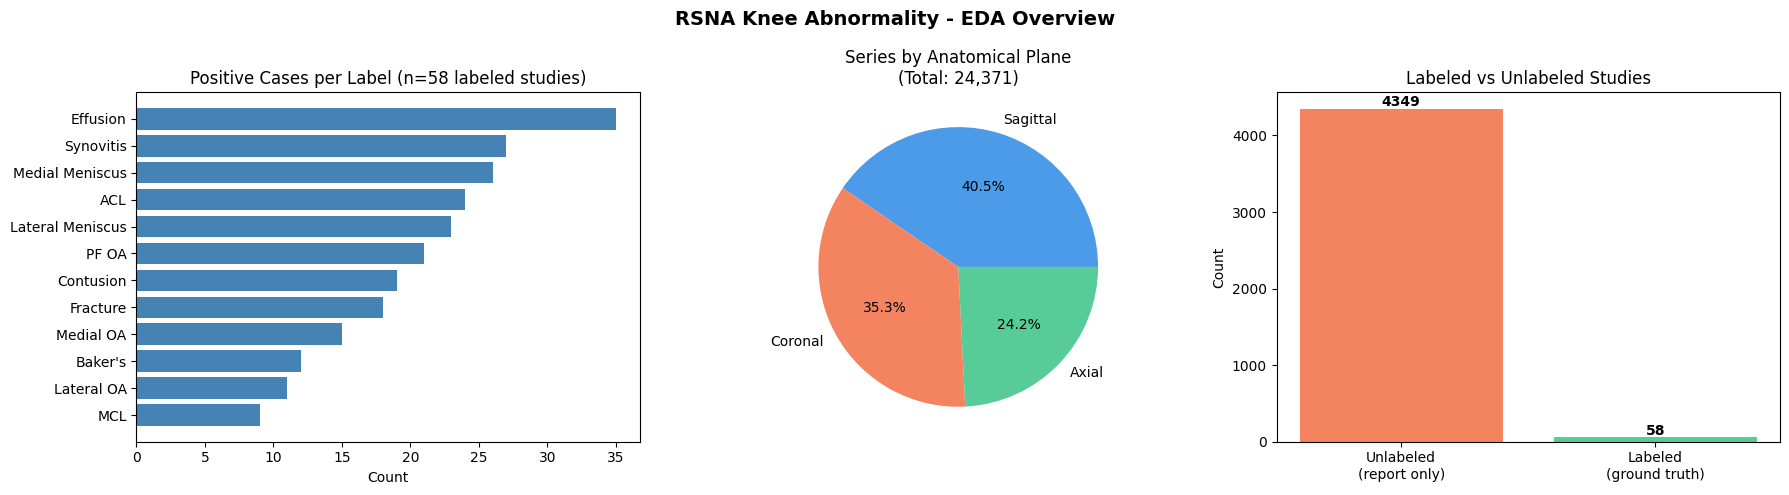

Saved!


In [36]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RSNA Knee Abnormality - EDA Overview", fontsize=14, fontweight='bold')

# 1. Label distribution (positive cases)
label_cols = dataset.LABEL_COLUMNS
pos_counts = dataset.db_study[label_cols].sum(skipna=True).sort_values(ascending=True)
axes[0].barh(pos_counts.index, pos_counts.values, color='steelblue')
axes[0].set_title("Positive Cases per Label (n=58 labeled studies)")
axes[0].set_xlabel("Count")

# 2. Anatomical plane distribution
plane_counts = dataset.db_series['Anatomical_Plane'].value_counts()
axes[1].pie(plane_counts.values, labels=plane_counts.index, autopct='%1.1f%%',
            colors=['#4C9BE8', '#F4845F', '#57CC99'])
axes[1].set_title("Series by Anatomical Plane\n(Total: 24,371)")

# 3. Labeled vs Unlabeled
labeled = dataset.db_study['is_labeled'].value_counts()
axes[2].bar(['Unlabeled\n(report only)', 'Labeled\n(ground truth)'],
            [labeled.get(0, 0), labeled.get(1, 0)],
            color=['#F4845F', '#57CC99'])
axes[2].set_title("Labeled vs Unlabeled Studies")
axes[2].set_ylabel("Count")
for i, v in enumerate([labeled.get(0, 0), labeled.get(1, 0)]):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Path: /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772/1.2.826.0.1.3680043.8.498.44435284380654338446078448674021394881.dcm
Image shape: (512, 512), dtype: uint16


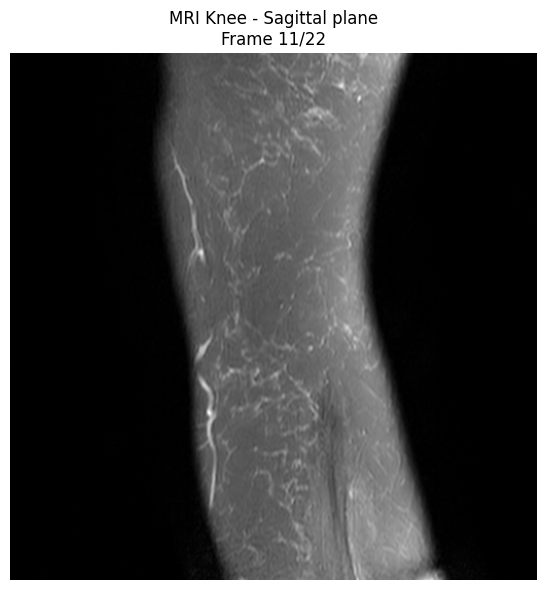

In [38]:
# Lấy đường dẫn ảnh trực tiếp
rows = dataset.get_image_rows(first_series)
mid = len(rows) // 2
img_path = dataset.get_image_path(first_series, frame_idx=mid)

print(f"Path: {img_path}")

# Đọc bằng pydicom
dcm = pydicom.dcmread(img_path)
img = dcm.pixel_array

print(f"Image shape: {img.shape}, dtype: {img.dtype}")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title(f"MRI Knee - Sagittal plane\nFrame {mid}/22")
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_mri.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Xem vài radiology report mẫu
print("=== RADIOLOGY REPORTS MẪU ===\n")

for i, row in dataset.db_study.head(3).iterrows():
    print(f"--- Study {i+1} ---")
    print(f"StudyInstanceUID: {row['StudyInstanceUID'][:30]}...")
    print(f"Labeled: {row['is_labeled']}")
    print(f"Report:\n{row['Report']}")
    print()

=== RADIOLOGY REPORTS MẪU ===

--- Study 1 ---
StudyInstanceUID: 1.2.826.0.1.3680043.8.498.1000...
Labeled: 0
Report:
Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame.

--- Study 2 ---
StudyInstanceUID: 1.2.826.0.1.3680043.8.498.1000...
Labeled: 0
Report:
[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor pd gewogen seq fs, cor T1 gewogen seq Bevindingen:

--- Study 3 ---
StudyInstanceUID: 1.2.826.0.1.3680043.8.498.1000...
Labeled: 0
Report:
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento

In [40]:
# Xem report của study có label
labeled_studies = dataset.db_study[dataset.db_study['is_labeled'] == 1]
row = labeled_studies.iloc[0]

print(f"StudyInstanceUID: {row['StudyInstanceUID'][:40]}...")
print(f"\nLabels:")
for col in dataset.LABEL_COLUMNS:
    val = row[col]
    if val == 1.0:
        print(f"  ✅ {col}")
    elif val == 0.0:
        print(f"  ❌ {col}")

print(f"\nReport:\n{row['Report']}")

StudyInstanceUID: 1.2.826.0.1.3680043.8.498.10095687747295...

Labels:
  ❌ ACL
  ❌ MCL
  ❌ Medial Meniscus
  ❌ Lateral Meniscus
  ❌ Medial OA
  ❌ Lateral OA
  ✅ PF OA
  ✅ Effusion
  ❌ Synovitis
  ❌ Baker's
  ❌ Contusion
  ❌ Fracture

Report:
Antecedentes Clínicos:
Esguince rodilla. [DATE].
Hallazgos:
No hay alteraciones de señal significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Amputación marginal del cuerpo del menisco lateral. Menisco medial de morfología y señal
conservada, sin signos de rotura.
Cartílagos de los compartimentos femorotibiales sin alteraciones.
Fina úlcera condral focal de espesor total del aspecto inferior de la vertiente medial de la tróclea
femoral con mínimos cambios óseos secundarios. Fenómenos condrales reparativos de la región
central de la simple femoral. Cartílago rotuliano sin alteraciones.
Leve derrame articular. No hay quistes poplíteos patológicos.
Aumento de señal de la inserción distal del tendón cuadricipi